In [48]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pickle

# **Step 2 — Load Dataset**

In [49]:
df = pd.read_csv('/content/customer_churn_data.csv')

**Check first 5 rows**





In [50]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


# Step 3 — Understand Dataset










In [51]:
df.shape


(1000, 10)

In [52]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [54]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [55]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


#Step 3.1 — Remove Unnecessary Column

Customer ID is not useful for prediction.

In [56]:
df.drop('CustomerID', axis=1, inplace=True)

#Step 3.2 — Handle TotalCharges Issue

This column is usually stored as object/string.

In [57]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [58]:
df.isnull().sum()

,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


In [59]:
df.dropna(inplace=True)

#Step 3.3 — Encode Target Column

In [60]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

#Step 3.4— Encode Categorical Features

In [61]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

#Step 4 — Exploratory Data Analysis

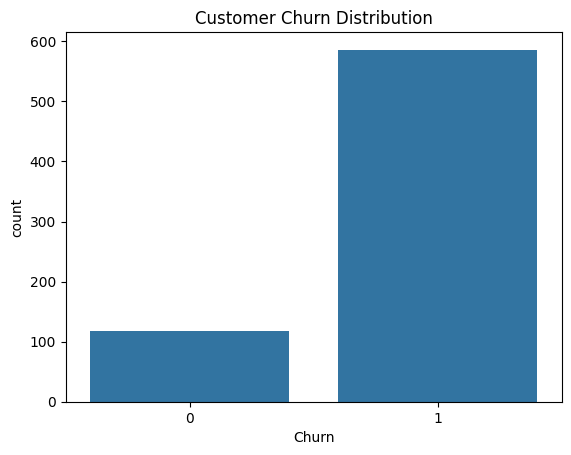

In [62]:
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

#Monthly Charges vs Churn

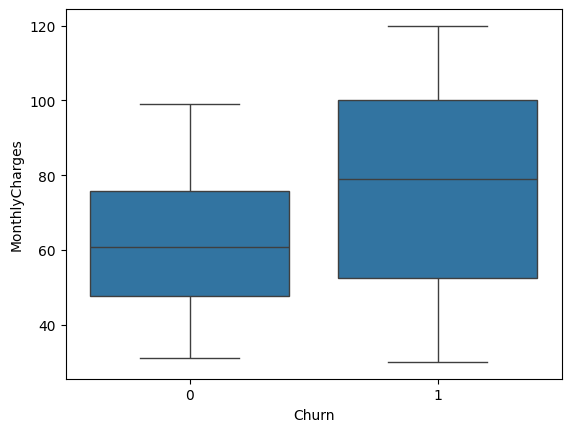

In [63]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

#Tenure vs Churn

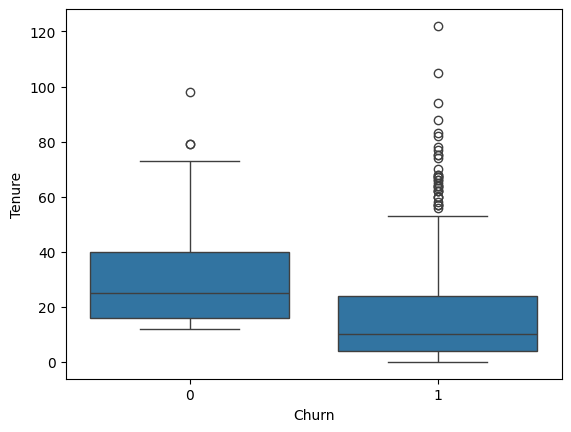

In [64]:
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.show()

#*Step* 5 — Split Features & Target

In [65]:
X = df.drop('Churn', axis=1)
y = df['Churn']

#Step 6 — Train Test Split

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

##PHASE  — Train ML Models
#Step 7 — Logistic Regression

In [67]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

#Step 8 — Evaluate *Model*

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.9078014184397163
Precision: 0.9140625
Recall: 0.9831932773109243
F1 Score: 0.9473684210526315


#Step 9 — Train Random *Forest*

In [69]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


#Step 10 — Evaluate Random Forest



In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


## PHASE — Confusion Matrix
#Step 11 — Visualize Confusion Matrix

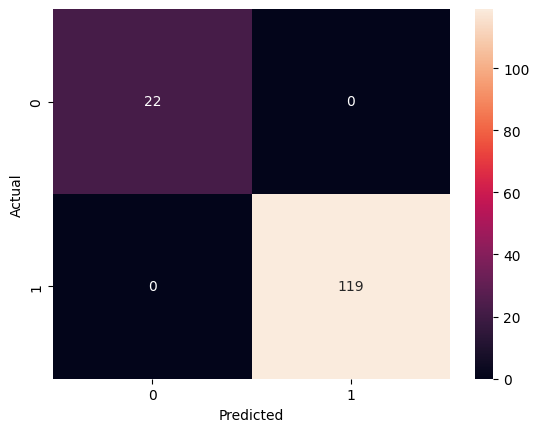

In [71]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Step 12 — Install Libraries in Colab

In [72]:
!pip install streamlit pyngrok



##PHASE  — Save Model
Step 12 — Save Trained Model


In [73]:
pickle.dump(rf, open('churn_model.pkl', 'wb'))

Step 13 — Save Column Names

In [74]:
pickle.dump(X.columns, open('model_columns.pkl', 'wb'))

#PHASE  — Streamlit App
###Step 1 — Create Streamlit App File

In [83]:
%%writefile app.py

import streamlit as st
import pandas as pd
import pickle

# Load model
model = pickle.load(open('churn_model.pkl', 'rb'))
model_columns = pickle.load(open('model_columns.pkl', 'rb'))

# Page Title
st.title("📊 Telecom Customer Churn Prediction System")

# Project Description
st.markdown("""
This AI-powered system predicts whether a telecom customer is likely to leave the company
based on customer billing, subscription, and service usage behavior.
""")

# Sidebar
st.sidebar.header("ℹ️ How to Use")

st.sidebar.info("""
1. Enter customer details
2. Click on Predict Churn
3. View customer churn risk
""")

# About Section
with st.expander("ℹ️ About This Project"):
    st.write("""
    This machine learning project analyzes telecom customer behavior
    and predicts churn probability using historical customer data.
    """)

# Customer Information Section
st.subheader("👤 Customer Information")

tenure = st.slider(
    "Customer Tenure (Months)",
    0,
    72,
    12,
    help="Number of months the customer stayed with the company"
)

# Billing Information Section
st.subheader("💳 Billing Information")

col1, col2 = st.columns(2)

with col1:
    MonthlyCharges = st.number_input(
        "Monthly Bill Amount",
        min_value=0.0,
        max_value=200.0,
        value=50.0
    )

with col2:
    TotalCharges = st.number_input(
        "Total Amount Paid",
        min_value=0.0,
        max_value=10000.0,
        value=500.0
    )

# Service Information Section
st.subheader("🌐 Service Information")

contract = st.selectbox(
    "Contract Type",
    ["Month-to-Month", "One Year", "Two Year"]
)

internet_service = st.selectbox(
    "Internet Service",
    ["DSL", "Fiber Optic", "No Internet"]
)

payment_method = st.selectbox(
    "Payment Method",
    [
        "Electronic Check",
        "Mailed Check",
        "Bank Transfer",
        "Credit Card"
    ]
)

# Encoding Maps
contract_map = {
    "Month-to-Month": 0,
    "One Year": 1,
    "Two Year": 2
}

internet_map = {
    "DSL": 0,
    "Fiber Optic": 1,
    "No Internet": 2
}

payment_map = {
    "Electronic Check": 0,
    "Mailed Check": 1,
    "Bank Transfer": 2,
    "Credit Card": 3
}

Contract = contract_map[contract]
InternetService = internet_map[internet_service]
PaymentMethod = payment_map[payment_method]

# Create input dataframe
input_data = pd.DataFrame([[
    tenure,
    MonthlyCharges,
    TotalCharges,
    Contract,
    InternetService,
    PaymentMethod
]], columns=[
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'InternetService',
    'PaymentMethod'
])

# Fill missing columns
for col in model_columns:
    if col not in input_data.columns:
        input_data[col] = 0

input_data = input_data[model_columns]

# Prediction
if st.button("Predict Churn"):

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0][1]

    st.metric(
        label="Churn Probability",
        value=f"{probability:.2%}"
    )

    if prediction == 1:

        st.error("⚠️ High Churn Risk Detected")

        st.write("""
        This customer shows behavior patterns commonly associated with churn:
        - Short customer tenure
        - High monthly billing
        - Flexible contract plans
        """)

    else:

        st.success("✅ Customer Likely to Stay")

        st.write("""
        This customer shows stable subscription behavior and lower churn risk.
        """)

# Footer
st.markdown("---")

st.caption(
    "Built using Machine Learning, Scikit-learn, and Streamlit"
)

Overwriting app.py


##Step 3 — Create Public URL

In [79]:
from pyngrok import ngrok

ngrok.set_auth_token("3DwJXutYY5KseuX11jJmVyDclgF_5Af653K9hfQZ8F5Diom1r")

##Step 2 — Run Streamlit in Colab

In [80]:
!streamlit run app.py &>/content/logs.txt &

In [84]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://dainty-come-dictator.ngrok-free.dev" -> "http://localhost:8501"
